In [1]:
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
iris = load_iris()
X =iris.data[:, :2]
y= iris.target

In [3]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
model = GaussianNB()
model.fit(x_train, y_train)

GaussianNB()

In [5]:
X_min, X_max = X[:, 0].min() - 1, X[:, 0].max() +1
Y_min, Y_max = X[:, 0].min() - 1, X[:, 0].max() +1

xx, yy = np.meshgrid(np.arange(X_min, X_max, 0.1),
                     np.arange(Y_min, Y_max, 0.1))

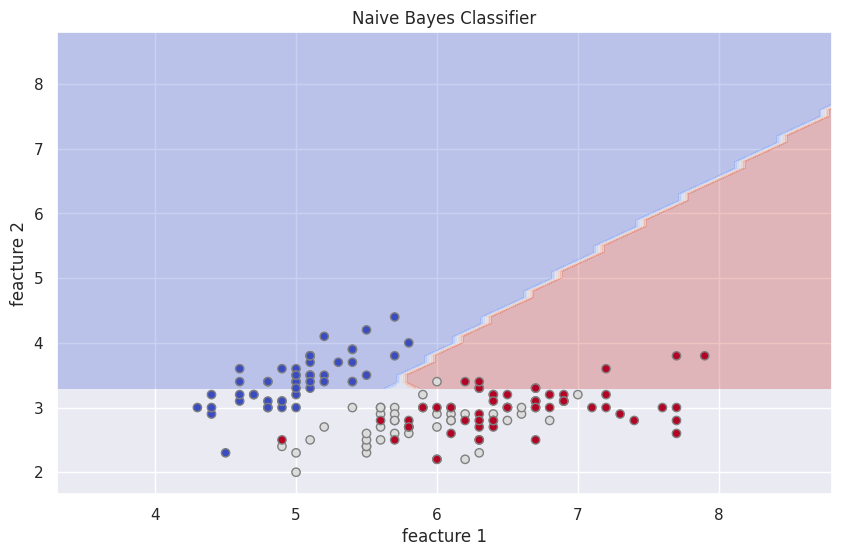

In [6]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


sns.set(style="darkgrid")
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y,
            cmap='coolwarm', edgecolors='gray')
plt.title('Naive Bayes Classifier')
plt.xlabel('feacture 1')
plt.ylabel('feacture 2')
plt.show()


# Ejercicio 1

In [7]:

datos = {
    'Sexo': ['Hombre', 'Hombre', 'Hombre', 'Hombre', 'Mujer', 'Mujer', 'Mujer', 'Mujer'],
    'Altura(Cm)': [ 183, 180, 170, 180, 152, 168, 165, 175],
    'Peso(Kg)': [81.6, 86.2, 77.1, 74.8, 45.4, 68.0, 59.0, 68.0],
    'Talla del pie(Cm)': [30.5, 27.9, 30.5, 25.4, 15.2, 20.3, 17.8, 22.9]
}
df = pd.DataFrame(datos)
df

,Sexo,Altura(Cm),Peso(Kg),Talla del pie(Cm)
0,Hombre,183,81.6,30.5
1,Hombre,180,86.2,27.9
2,Hombre,170,77.1,30.5
3,Hombre,180,74.8,25.4
4,Mujer,152,45.4,15.2
5,Mujer,168,68.0,20.3
6,Mujer,165,59.0,17.8
7,Mujer,175,68.0,22.9


In [8]:
# calificar a alguien si es hombre o mujer por sus medidas: peso, altura y numero de pie
df['Sexo_num'] = df['Sexo'].map({'Hombre': 0, 'Mujer': 1})

X = df[['Altura(Cm)', 'Peso(Kg)', 'Talla del pie(Cm)']].values
y = df['Sexo_num'].values

# 2. Entrenar el modelo
model = GaussianNB()
model.fit(X, y)

GaussianNB()

In [9]:
x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

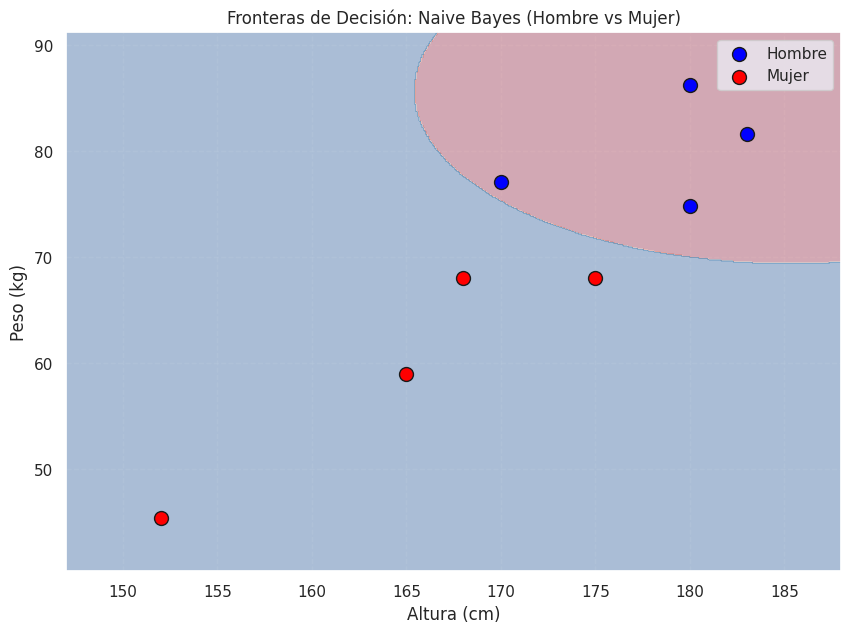

In [10]:
import numpy as np
# Calculate the mean of the third feature (Talla del pie(Cm)) to hold it constant
third_feature_mean = X[:, 2].mean()

X_grid_predict = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, third_feature_mean)]
Z = model.predict(X_grid_predict)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

# Pintar las regiones de decisión (fondo)
plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.3)

# Dibujar los puntos de los datos reales
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Hombre', edgecolors='k', s=100)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Mujer', edgecolors='k', s=100)

# Personalización
plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.title('Fronteras de Decisión: Naive Bayes (Hombre vs Mujer)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Ejercicio 2: Clasificación de Juego Basado en Clima y Temperatura

Este ejercicio tiene como objetivo clasificar si un juego se jugó o no, basándose en las condiciones climáticas y la temperatura. Para ello, crearemos una tabla (DataFrame) con datos de ejemplo.

In [11]:
import pandas as pd

datos_juego = {
    'Clima': ['Soleado', 'Soleado', 'Nublado', 'Lluvioso', 'Lluvioso', 'Lluvioso', 'Nublado', 'Soleado', 'Soleado', 'Lluvioso'],
    'Temperatura': ['Caluroso', 'Caluroso', 'Caluroso', 'Suave', 'Frio', 'Frio', 'Frio', 'Suave', 'Frio', 'Suave'],
    'Humedad': ['Alta', 'Alta', 'Alta', 'Alta', 'Normal', 'Normal', 'Normal', 'Alta', 'Normal', 'Normal'],
    'Viento': ['Debil', 'Fuerte', 'Debil', 'Debil', 'Debil', 'Fuerte', 'Fuerte', 'Debil', 'Debil', 'Fuerte'],
    'Se_Jugo': ['No', 'No', 'Si', 'Si', 'Si', 'No', 'Si', 'No', 'Si', 'Si']
}

df_juego = pd.DataFrame(datos_juego)
display(df_juego)

,Clima,Temperatura,Humedad,Viento,Se_Jugo
0,Soleado,Caluroso,Alta,Debil,No
1,Soleado,Caluroso,Alta,Fuerte,No
2,Nublado,Caluroso,Alta,Debil,Si
3,Lluvioso,Suave,Alta,Debil,Si
4,Lluvioso,Frio,Normal,Debil,Si
5,Lluvioso,Frio,Normal,Fuerte,No
6,Nublado,Frio,Normal,Fuerte,Si
7,Soleado,Suave,Alta,Debil,No
8,Soleado,Frio,Normal,Debil,Si
9,Lluvioso,Suave,Normal,Fuerte,Si


In [12]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying the original DataFrame
df_juego_encoded = df_juego.copy()

# Initialize LabelEncoders for each categorical column
le_clima = LabelEncoder()
le_temperatura = LabelEncoder()
le_humedad = LabelEncoder()
le_viento = LabelEncoder()
le_se_jugo = LabelEncoder()

# Apply Label Encoding
df_juego_encoded['Clima'] = le_clima.fit_transform(df_juego_encoded['Clima'])
df_juego_encoded['Temperatura'] = le_temperatura.fit_transform(df_juego_encoded['Temperatura'])
df_juego_encoded['Humedad'] = le_humedad.fit_transform(df_juego_encoded['Humedad'])
df_juego_encoded['Viento'] = le_viento.fit_transform(df_juego_encoded['Viento'])
df_juego_encoded['Se_Jugo'] = le_se_jugo.fit_transform(df_juego_encoded['Se_Jugo'])

display(df_juego_encoded)

,Clima,Temperatura,Humedad,Viento,Se_Jugo
0,2,0,0,0,0
1,2,0,0,1,0
2,1,0,0,0,1
3,0,2,0,0,1
4,0,1,1,0,1
5,0,1,1,1,0
6,1,1,1,1,1
7,2,2,0,0,0
8,2,1,1,0,1
9,0,2,1,1,1


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Define features (X) and target (y)
X_juego = df_juego_encoded[['Clima', 'Temperatura', 'Humedad', 'Viento']]
y_juego = df_juego_encoded['Se_Jugo']

# Split data into training and testing sets
X_train_juego, X_test_juego, y_train_juego, y_test_juego = train_test_split(X_juego, y_juego, test_size=0.3, random_state=42)

# Initialize and train the Gaussian Naive Bayes model
model_juego = GaussianNB()
model_juego.fit(X_train_juego, y_train_juego)

GaussianNB()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


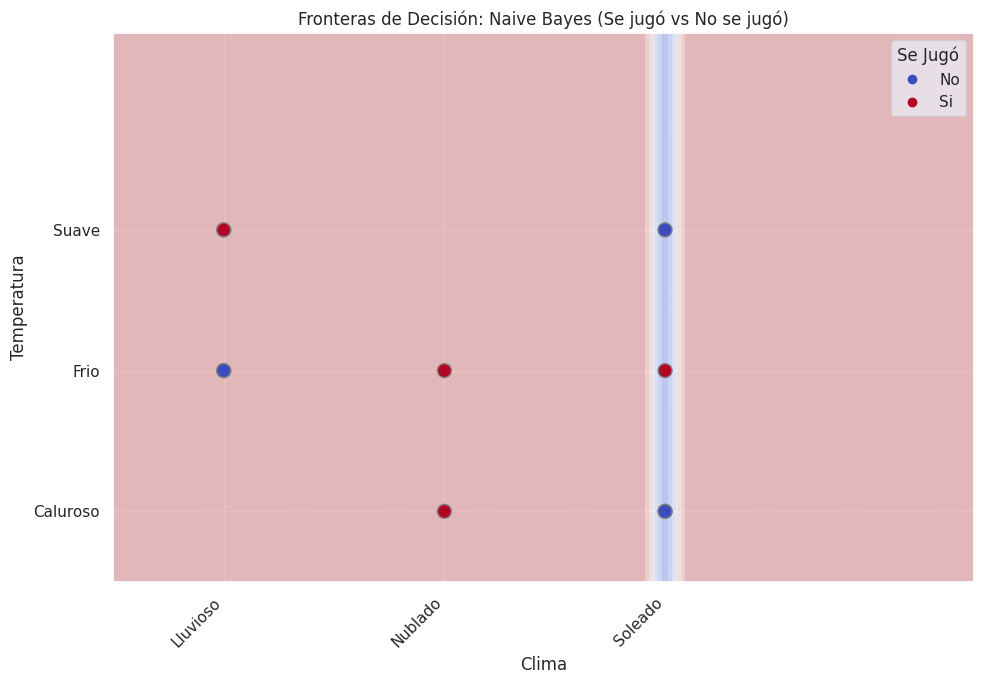

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Get the modes of 'Humedad' and 'Viento' from the training data
mode_humedad = X_train_juego['Humedad'].mode()[0]
mode_viento = X_train_juego['Viento'].mode()[0]

# Define the ranges for the features to be plotted (Clima and Temperatura)
clima_min, clima_max = X_juego['Clima'].min(), X_juego['Clima'].max()
temp_min, temp_max = X_juego['Temperatura'].min(), X_juego['Temperatura'].max()

# Create a meshgrid for Clima and Temperatura.
# Adjusting boundaries to cover discrete points well for contourf.
xx, yy = np.meshgrid(np.arange(clima_min - 0.5, clima_max + 1.5, 0.1),
                     np.arange(temp_min - 0.5, temp_max + 1.5, 0.1))

# Prepare the input for prediction, fixing Humedad and Viento at their modes
X_grid_predict = np.c_[xx.ravel(), yy.ravel(),
                       np.full(xx.ravel().shape, mode_humedad),
                       np.full(xx.ravel().shape, mode_viento)]

# Make predictions using the trained model for Ejercicio 2
Z_juego = model_juego.predict(X_grid_predict)
Z_juego = Z_juego.reshape(xx.shape)

plt.figure(figsize=(10, 7))

# Plot the decision regions
plt.contourf(xx, yy, Z_juego, alpha=0.3, cmap='coolwarm')

# Plot the actual data points
scatter = plt.scatter(X_juego['Clima'], X_juego['Temperatura'], c=y_juego,
            cmap='coolwarm', edgecolors='gray', s=100)

# Get original labels for 'Se_Jugo' from the LabelEncoder
se_jugo_labels = le_se_jugo.inverse_transform([0, 1])

# Create a legend for the scatter points
handles, labels = scatter.legend_elements()
legend_labels_map = {0: se_jugo_labels[0], 1: se_jugo_labels[1]}
legend_labels = [legend_labels_map[int(label.split('{')[-1].split('}')[0])] for label in labels]

plt.title('Fronteras de Decisión: Naive Bayes (Se jugó vs No se jugó)')
plt.xlabel('Clima')
plt.ylabel('Temperatura')

# Map encoded integer ticks back to original categorical labels
plt.xticks(ticks=range(len(le_clima.classes_)), labels=le_clima.classes_, rotation=45, ha='right')
plt.yticks(ticks=range(len(le_temperatura.classes_)), labels=le_temperatura.classes_)

plt.legend(handles=handles, labels=legend_labels, title="Se Jugó")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()